# Smart Waste Classification System

# Notebook 03 — Exploratory Data Analysis

**Author:** Syed Soban Mudassar

---

## Purpose

This notebook explores the TrashNet dataset using statistical summaries and
visualizations.

The objective is to understand the dataset before preprocessing and model
development.

Exploratory Data Analysis (EDA) helps identify patterns, class imbalance,
potential biases, and characteristics that influence machine learning model
performance.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
current_dir = Path.cwd()
project_root = current_dir.parent

dataset_path = project_root / "data" / "raw" / "trashnet"

In [3]:
classes = sorted(
    folder.name
    for folder in dataset_path.iterdir()
    if folder.is_dir()
)

class_counts = {}

for class_name in classes:
    folder = dataset_path / class_name

    count = len(list(folder.glob("*.jpg")))

    class_counts[class_name] = count

df = pd.DataFrame(
    {
        "Class": class_counts.keys(),
        "Images": class_counts.values(),
    }
)

df

,Class,Images
0,cardboard,403
1,glass,501
2,metal,410
3,paper,594
4,plastic,482
5,trash,137


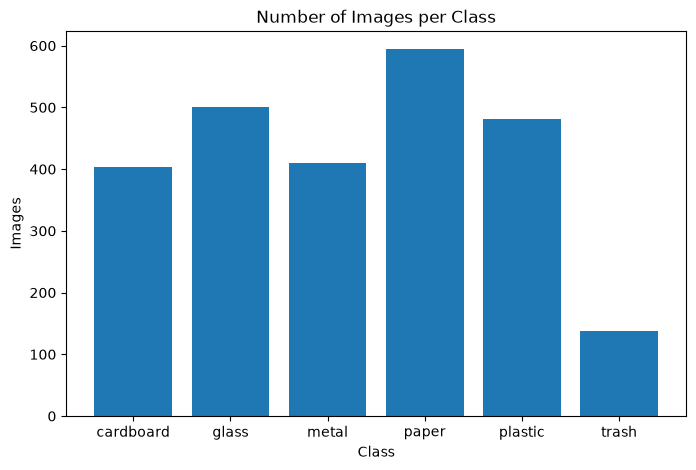

In [4]:
plt.figure(figsize=(8,5))

plt.bar(
    df["Class"],
    df["Images"],
)

plt.title("Number of Images per Class")

plt.xlabel("Class")

plt.ylabel("Images")

plt.show()

##  Class Distribution Observation

The dataset is not evenly balanced.

The `paper` class contains the largest number of images, while the `trash`
class contains the fewest.

This imbalance may influence model performance because machine learning models
often become biased toward classes with more training examples.

Data augmentation and evaluation metrics will later help reduce this issue.

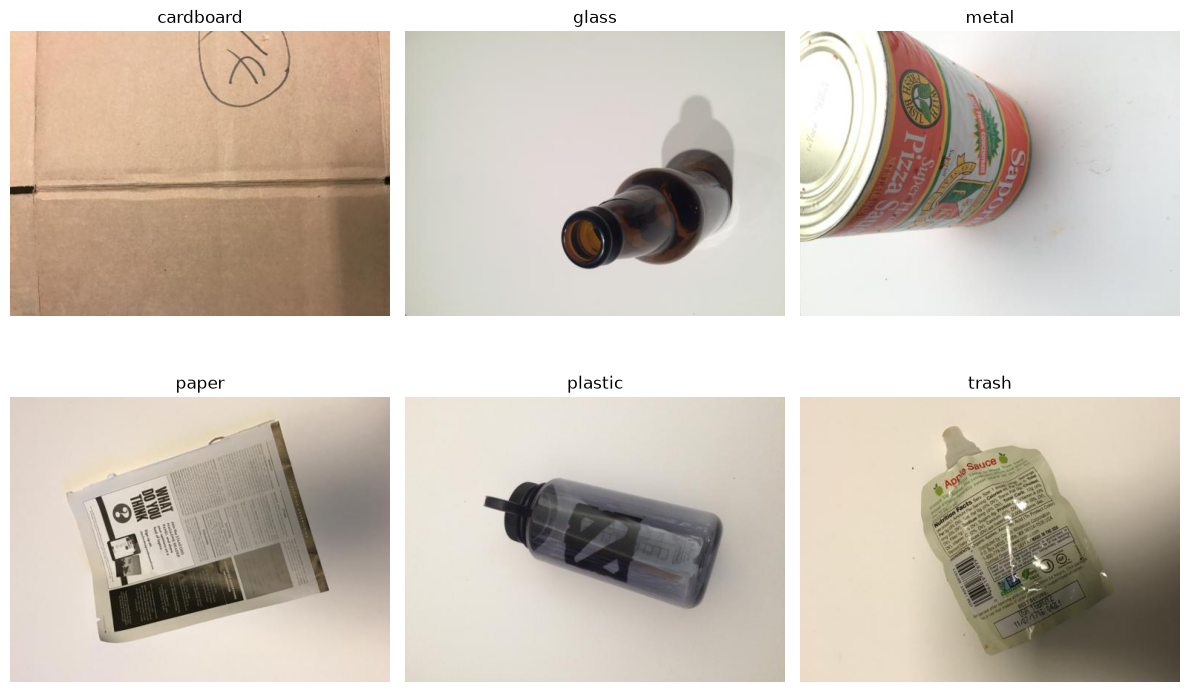

In [5]:
from PIL import Image

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
)

axes = axes.flatten()

for axis, class_name in zip(axes, classes):

    image_path = next((dataset_path / class_name).glob("*.jpg"))

    image = Image.open(image_path)

    axis.imshow(image)

    axis.set_title(class_name)

    axis.axis("off")

plt.tight_layout()

plt.show()

##  Sample Image Observation

The sample images show clear visual differences between the six classes.

Most images contain a single dominant waste object positioned near the center
of the frame.

The backgrounds appear relatively controlled, which simplifies the
classification task compared with real-world environments.

In [6]:
from collections import Counter

from PIL import Image

dimension_counter = Counter()

for class_name in classes:

    for image_path in (dataset_path / class_name).glob("*.jpg"):

        image = Image.open(image_path)

        dimension_counter[image.size] += 1

dimension_df = pd.DataFrame(
    dimension_counter.items(),
    columns=["Dimensions", "Count"],
)

dimension_df.sort_values(
    "Count",
    ascending=False,
)

,Dimensions,Count
0,"(512, 384)",2527


##  Image Dimension Observation

Most images share the same resolution.

This consistency simplifies preprocessing because the images can be resized
using a common transformation pipeline before training.

Although the original dimensions are already consistent, all images will still
be resized to match the input size required by the selected neural network
architecture.

In [7]:
import numpy as np

In [8]:
red_values = []
green_values = []
blue_values = []

for class_name in classes:

    for image_path in (dataset_path / class_name).glob("*.jpg"):

        image = Image.open(image_path).convert("RGB")

        image_array = np.array(image)

        red_values.append(image_array[:, :, 0].mean())
        green_values.append(image_array[:, :, 1].mean())
        blue_values.append(image_array[:, :, 2].mean())

print("Average Red:", np.mean(red_values))
print("Average Green:", np.mean(green_values))
print("Average Blue:", np.mean(blue_values))

Average Red: 171.63462329819717
Average Green: 163.14863227951923
Average Blue: 154.2300176646901


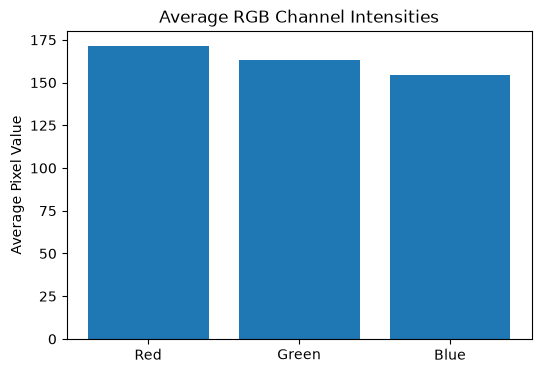

In [9]:
channel_names = ["Red", "Green", "Blue"]

channel_means = [
    np.mean(red_values),
    np.mean(green_values),
    np.mean(blue_values),
]

plt.figure(figsize=(6,4))

plt.bar(channel_names, channel_means)

plt.title("Average RGB Channel Intensities")

plt.ylabel("Average Pixel Value")

plt.show()

##  RGB Color Observation

The average red, green, and blue intensities are relatively similar.

This indicates that the dataset contains standard RGB photographs rather than
grayscale images or images dominated by a single color channel.

Although the channel averages are reasonably balanced, pixel normalization
will still be applied during preprocessing to improve training stability.

In [10]:
aspect_ratios = []

for class_name in classes:

    for image_path in (dataset_path / class_name).glob("*.jpg"):

        image = Image.open(image_path)

        width, height = image.size

        aspect_ratios.append(width / height)

print("Minimum aspect ratio:", min(aspect_ratios))
print("Maximum aspect ratio:", max(aspect_ratios))
print("Average aspect ratio:", np.mean(aspect_ratios))

Minimum aspect ratio: 1.3333333333333333
Maximum aspect ratio: 1.3333333333333333
Average aspect ratio: 1.3333333333333335


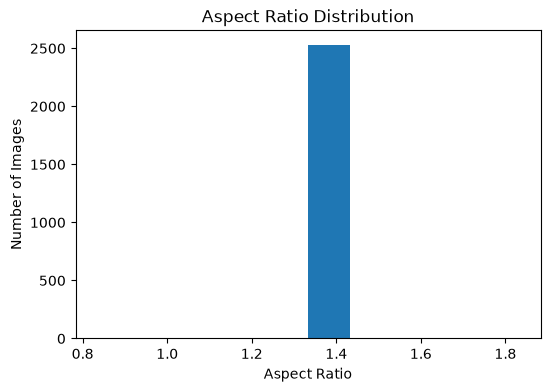

In [11]:
plt.figure(figsize=(6,4))

plt.hist(aspect_ratios, bins=10)

plt.title("Aspect Ratio Distribution")

plt.xlabel("Aspect Ratio")

plt.ylabel("Number of Images")

plt.show()

##  Aspect Ratio Observation

The aspect ratios are highly consistent across the dataset.

This reduces preprocessing complexity because resizing the images is less
likely to introduce severe geometric distortion.

A fixed input size can therefore be used safely during model training.

#  Overall Exploratory Data Analysis Summary

The exploratory analysis identified several important characteristics of the
TrashNet dataset.

## Positive Findings

- Clear folder organization
- Consistent image dimensions
- JPEG image format
- Standard RGB images
- One dominant object per image
- Controlled backgrounds

## Identified Challenges

- Class imbalance
- Three groups of exact duplicate images
- Limited dataset size
- Controlled imaging conditions

These observations will influence preprocessing, augmentation, model
selection, and evaluation during later stages of the project.